# **Bài toán Hồi quy tuyến tính (Dự đoán Nhiệt độ)**

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Tải dữ liệu
from google.colab import files
files.upload()

Saving temperatures.csv to temperatures.csv


{'temperatures.csv': b'Farenheit,Celcius\n-58,-50\n-40,-40\n-22,-30\n-4,-20\n14,-10\n19.4,-7\n26.6,-3\n32,0\n46.4,8\n50,10\n59,15\n68,20\n71.6,22\n86,30\n100.4,38'}

In [4]:
# Đọc dữ liệu cho sẵn từ file
df = pd.read_csv('temperatures.csv')
df

,Farenheit,Celcius
0,-58.0,-50
1,-40.0,-40
2,-22.0,-30
3,-4.0,-20
4,14.0,-10
5,19.4,-7
6,26.6,-3
7,32.0,0
8,46.4,8
9,50.0,10


Nên chuyển đổi dữ liệu input và output thành dạng `numpy.ndarray` để phù hợp với yêu cầu đầu vào của mạng Neuron.

In [5]:
f_input = df["Farenheit"].to_numpy()
c_output = df["Celcius"].to_numpy()
type(f_input), type(c_output)

(numpy.ndarray, numpy.ndarray)

## **Xây dựng - Huấn luyện mô hình**

In [6]:
from tensorflow import keras

# Cố định kết quả ngẫu nhiên để các lần chạy giống nhau
keras.utils.set_random_seed(42)

Mô hình tuần tự `Sequential` cần xây dựng gồm 2 layer `Dense`.\
Layer `Dense` là layer kết nối tất cả các node ở layer trước đến layer sau nó, nhận vào các tham số:
* `units`: số node trong layer Dense (tuỳ chọn)
* `input_shape`: đầu ra của layer Dense (phụ thuộc vào dữ liệu)

Mô hình sẽ được huấn luyện với tham số `loss='mean_squared_error'` và `optimizer='adam'`

In [8]:
model = keras.Sequential([
    # Layer Dense #1 có 10 neurons, input_shape = 1 vì đầu vào chỉ có 1 số duy nhất (độ F)
    keras.layers.Dense(units=10, input_shape=[1]),
     # Layer Dense #2 là layer output, có units=1 vì kết quả dự đoán là 1 số (độ C)
    keras.layers.Dense(units=1)
    ])

# mean_square_error (bình phương sai số): càng gần 0 càng tốt
model.compile(loss="mean_squared_error", optimizer='adam')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

Huấn luyện mô hình bằng phương thức `fit` nhận vào các tham số:
* Dữ liệu input (tham số #1)
* Dữ liệu output (tham số #2)
* `epochs`: số lần huấn luyện trên dữ liệu

Lệnh kích hoạt quá trình học. Máy sẽ đọc đi đọc lại toàn bộ dữ liệu 100 lần để tự điều chỉnh các tham số toán học bên trong cho chính xác.

In [13]:
model.fit(f_input, c_output, epochs=100)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 205.4733
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 205.3576
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 205.2419
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 205.1263
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 205.0108
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 204.8953
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 204.7800
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 204.6646
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 204.5493
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 204.4341
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 204.3190
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 204.2038
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 204.0887
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 203.9736
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss

## **Dự đoán**

Cho độ F cần chuyển đổi là 90.\
Hãy sử dụng phương thức `predict()` của mô hình để dự đoán độ C tương ứng.

In [14]:
input = np.array([90])
prediction = model.predict(input)
# Kết quả dự đoán
print(input, "Degree Farenheit is predicted as", prediction[0], "Degree Celcius")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[90] Degree Farenheit is predicted as [33.040257] Degree Celcius


Sử dụng công thức chuyển đổi truyền thống để tính kết quả độ C chính xác.\
So sánh với kết quả dự đoán của mô hình.

In [12]:
print("Expected value is", round((input[0]-32)/1.8, 5), "Degree Celcius")

Expected value is 32.22222 Degree Celcius


# **Phân Loại Chữ Số Viết Tay (Bộ dữ liệu MNIST)**

Đây là bài toán Thị giác máy tính nâng cao sử dụng mạng CNN để nhận diện các chữ số từ 0 đến 9.

## **Chuẩn bị dữ liệu**
Keras tích hợp sẵn bộ dữ liệu kinh điển MNIST gồm 70,000 ảnh chữ số viết tay.

- Tải bộ dữ liệu MNIST từ keras sử dụng keras.datasets.mnist.load_data và chia thành hai tập train, test.
- X_train chứa 60,000 ảnh dùng để học, X_test chứa 10,000 ảnh giữ lại để kiểm tra (test) mô hình.
- Kích thước (28, 28) nghĩa là mỗi bức ảnh rộng 28 pixel và cao 28 pixel.


In [15]:
(X_train, Y_train), (X_test, Y_test) = keras.datasets.mnist.load_data()
print(X_train.shape, X_test.shape) # Kết quả: ((60000, 28, 28), (10000, 28, 28))
print(Y_train.shape, Y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (10000, 28, 28)
(60000,) (10000,)


In [16]:
# Để biểu diễn thử một ảnh từ bộ dữ liệu, ta sử dụng thư viện `PIL` và `matplotlib.pyplot`
from PIL import Image
import matplotlib.pyplot as plt

Chọn ảnh đầu tiên trong tập `X_train` và vẽ ảnh bằng plt.\
Chọn tên của ảnh là label trong tập `Y_train` tương ứng với chỉ số của ảnh.

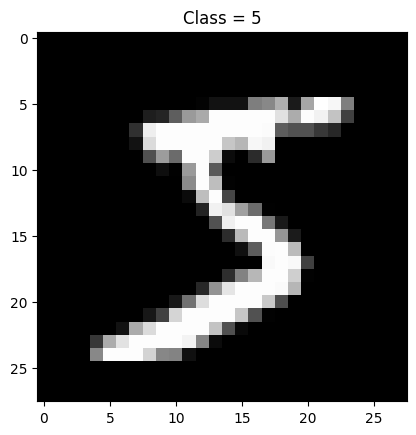

In [17]:
img = Image.fromarray(X_train[0])
plt.imshow(img, cmap='gray')
plt.title(f"Class = {Y_train[0]}")
plt.show()

# **Biến đổi dữ liệu X**
Các pixel ảnh gốc có giá trị từ 0 đến 255. Việc chia cho 255 đưa tất cả về khoảng $[0, 1]$, giúp mô hình tính toán nhanh hơn và không bị bùng nổ gradient khi huấn luyện.

In [18]:
x_train = X_train.astype("float32") / 255
x_test = X_test.astype("float32") / 255

Ta cần đảm bảo dữ liệu x_train và x_test vào có format `(n, w, h, d)` để huấn luyện.

Trong đó:
* `n` là số hình
* `w` là chiều rộng
* `h` là chiều cao
* `d` là số chiều (ở bài tập này ta chọn d=1 vì hình trắng đen, nếu hình có màu RGB thì d=3)

Sử dụng `np.expand_dims()` để thêm chiều ở cuối.
> *Ví dụ: x_train có shape là `(60000, 28, 28)` cần phải được chuyển sang shape là `(60000, 28, 28, 1)`*


In [20]:
# Thêm chiều ở cuối
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Kiểm tra lại shape
print("x_train new shape:", x_train.shape)

x_train new shape: (60000, 28, 28, 1, 1)


Cần chuyển kiểu dữ liệu của y_train và y_test từ dạng số (numerical) sang dạng phân loại (categorical).
> *Ví dụ: y_train có shape là (60000,) cần phải được chuyển sang shape mới là (60000, số_lớp)*

Giải thích (One-hot Encoding): Nhãn gốc Y_train là các số như 5, 7, 3. Máy tính phân loại tốt nhất khi đưa về dạng mảng nhị phân.
<br>
Ví dụ: Số 3 sẽ biến thành mảng vị trí: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0] (vị trí thứ 3 bằng 1, còn lại bằng 0).

In [21]:
num_classes = 10  # từ 0 đến 9 là 10 loại (class)
y_train = keras.utils.to_categorical(Y_train, num_classes)
y_test = keras.utils.to_categorical(Y_test, num_classes)
print(y_train.shape)
print(y_test.shape)

(60000, 10)
(10000, 10)


## **Thiết lập mạng CNN (Convolutional Neural Network)**

**Cơ chế quét ảnh**
- Conv2D(32, kernel_size=(3,3)): Tạo ra 32 bộ lọc (kích thước 3x3) trượt khắp bức ảnh để tìm các đặc trưng hình học (nét thẳng, nét cong của chữ số).
- MaxPooling2D(pool_size=(2,2)): Cứ mỗi ô vuông 2x2, lớp này chỉ giữ lại giá trị lớn nhất. Giúp ảnh nhỏ đi một nửa nhưng giữ lại các đường nét đậm nhất.
- Flatten(): Đập dẹt ma trận tính năng đang ở dạng 2D thành một chuỗi 1D (gồm 1600 số liên tiếp).
- Dense(10, activation='softmax'): Lớp cuối cùng đưa ra 10 con số ứng với xác suất của 10 chữ số (từ 0 đến 9). Hàm kích hoạt softmax đảm bảo tổng xác suất đoán của 10 ô này luôn bằng $1.0$ (tức 100%).

- Dùng loss="categorical_crossentropy" (chuẩn cho bài toán phân loại nhiều lớp). batch_size=128 có nghĩa là máy sẽ bốc 128 bức ảnh ra học cùng một lúc rồi mới cập nhật trọng số một lần, giúp tận dụng tối đa sức mạnh phần cứng.

In [23]:
# Khai báo lại input_shape với kích thước đầu vào là (h, w, d) đã xác định.
input_shape = (28, 28, 1)   # Ảnh trắng đen nên có chiều là 1

model = keras.Sequential([
    keras.layers.Conv2D(32, kernel_size=(3, 3), input_shape=input_shape),    # Layer tích chập
    keras.layers.MaxPooling2D(pool_size=(2,2)),                              # Layer MaxPool luôn theo sau layer Conv
    keras.layers.Conv2D(64, kernel_size=(3, 3)),                             # Thêm layer tích chập để tăng độ phức tạp (học được nhiều thông tin hơn)
    keras.layers.MaxPooling2D(pool_size=(2,2)),                              # Layer MaxPool tương ứng
    keras.layers.Flatten(),                                                  # Chỉ có một layer flatten trong mô hình
    keras.layers.Dense(num_classes, activation='softmax'),                   # Layer phân loại
])

model.compile(optimizer='adam',
              loss="categorical_crossentropy",     # Thay đổi loss cho phù hợp với mục tiêu bài toán là phân loại
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

## **Huấn luyện mô hình**

## Huấn luyện mô hình
Huấn luyện mô hình với `batch_size=128` và `epochs=5`.
* `batch_size` là số ảnh được xử lý mỗi lần mô hình cập nhật
* `epochs` là số lần huấn luyện trên dữ liệu

Ta sử dụng thêm tham số `validation_split` để tách 10% từ tập train thành tập validation, đảm bảo mô hình không bị thiên kiến (biased) với dữ liệu tập train.

In [24]:
batch_size = 128
epochs = 5
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.9203 - loss: 0.2900 - val_accuracy: 0.9772 - val_loss: 0.0840
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.9750 - loss: 0.0841 - val_accuracy: 0.9823 - val_loss: 0.0614
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.9810 - loss: 0.0631 - val_accuracy: 0.9830 - val_loss: 0.0564
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 56ms/step - accuracy: 0.9838 - loss: 0.0530 - val_accuracy: 0.9835 - val_loss: 0.0543
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.9860 - loss: 0.0461 - val_accuracy: 0.9835 - val_loss: 0.0545


## **Đánh giá mô hình**

Sử dụng phương thức `evaluate` để đánh giá mô hình trên tập test.\
Hàm sẽ trả về một tuple chứa giá trị loss và accuracy trên tập test.

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test accuracy:", accuracy)

## **Dự đoán thửu 1 hình**

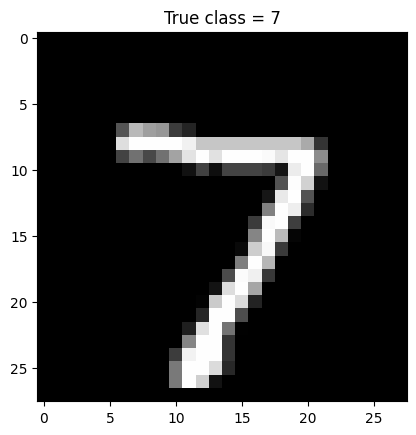

In [25]:
# Lấy hình đầu tiên trong tập test và vẽ bằng matplotlib.
test_img = X_test[0]
img = Image.fromarray(test_img)
plt.imshow(img, cmap='gray')
plt.title(f"True class = {Y_test[0]}")
plt.show()

Vì layer Dense ở cuối có 10 units nên kết quả của `predict` cũng trả về một numpy array có 10 giá trị, mỗi giá trị là tỉ lệ mà hình thuộc lớp tương ứng.
> Ví dụ: Mô hình phân loại 4 lớp có kết quả predict là `[0.1, 0.2, 0.7, 0.0]` nghĩa là hình có 10% thuộc lớp thứ nhất, 20% thuộc lớp thứ hai, 70% thuộc lớp thứ ba và 0% thuộc lớp cuối cùng.

> Lưu ý: Tổng tất cả các tỉ lệ của mảng kết quả luôn bằng 1, tương ứng với 100%.

In [26]:
test_img = np.expand_dims(test_img, 0) # Thêm chiều n=1 để đảm bảo hình có đủ các chiều (n, h, w)
preds = model.predict(test_img)
preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]], dtype=float32)

Sử dụng `np.argmax()` để lấy số thứ tự của lớp mà mô hình tự tin nhất.\
Ở đây số thứ tự vô tình trùng với tên của các lớp chữ số 0...9.

In [27]:
test_prediction  = np.argmax(preds)
print("Predicted class:", test_prediction)

Predicted class: 7


<!-- Thê -->